model_1_20 : lstm  + gru with dropout ||
model_1_nodrop : lstm + gru wihtout dropout ||
model_2_cnn : cnn ||
model 4 : cnn large ||
model 5 : cnn large + dropout ||
model 6 : cnn+gru||



# Helper function ( plotting curves , creating data frame , comparing models etc)



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def visualize_results(df=df_sorted):
    import numpy as np
    x = np.arange(len(df["model name"]))

    plt.figure(figsize=(12, 6))

    plt.bar(x - 0.2, df_sorted["train_accuracy"], width=0.4, label="train Accuracy")
    plt.bar(x + 0.2, df_sorted["train_loss"], width=0.4, label="train Loss")

    plt.xticks(x, df_sorted["model name"], rotation=45)
    plt.title(" Train Accuracy and Train Loss ")
    plt.legend()
    plt.show()




    plt.figure(figsize=(12, 6))

    plt.bar(x - 0.2, df_sorted["val_accuracy"], width=0.4, label="Val Accuracy")
    plt.bar(x + 0.2, df_sorted["val_loss"], width=0.4, label="Val Loss")

    plt.xticks(x, df_sorted["model name"], rotation=45)
    plt.title(" Validation Accuracy and Validation loss")
    plt.legend()
    plt.show()



    plt.figure(figsize=(12, 6))

    plt.bar(x - 0.2, df_sorted["train_accuracy"], width=0.4, label="train Accuracy")
    plt.bar(x + 0.2, df_sorted["val_accuracy"], width=0.4, label="val_acc")

    plt.xticks(x, df_sorted["model name"], rotation=45)
    plt.title("Train Accuracy and Validation Accuracy")
    plt.legend()
    plt.show()


    plt.figure(figsize=(12, 6))

    plt.bar(x - 0.2, df_sorted["train_loss"], width=0.4, label="train_loss")
    plt.bar(x + 0.2, df_sorted["val_loss"], width=0.4, label="val_loss")

    plt.xticks(x, df_sorted["model name"], rotation=45)
    plt.title("Train loss and Validation loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 6))


    plt.bar(x + 0.2, df_sorted["parameter_number"], width=0.4, label="param counts",   color="red")

    plt.xticks(x, df_sorted["model name"], rotation=40)
    plt.title("Parameter Number")
    plt.legend()
    plt.show()

In [266]:
#plotting model curve

def plot_loss_curves(history):

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

In [252]:
# comparing model val accuracy
def compare_loss_curves(models):

 for i in models:

    loss = i.history['loss']
    val_loss = i.history['val_loss']

    accuracy = i.history['accuracy']
    val_accuracy = i.history['val_accuracy']

    epochs = range(1, 21)

    # Plot loss
    plt.plot(epochs, loss, label='training_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.figure()
    plt.plot(epochs, accuracy, label='training_accuracy')
    plt.plot(epochs, val_accuracy, label='val_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

In [327]:
import pandas as pd

def create_model_df(model_names, models_history):

    params = []
    val_acc = []
    val_loss = []
    train_acc = []
    train_loss = []


    for model in model_names:
        params.append(model.count_params())


    for i in models_history:
        val_acc.append(i.history['val_accuracy'][-1])
        val_loss.append(i.history['val_loss'][-1])
        train_loss.append(i.history['loss'][-1])
        train_acc.append(i.history['accuracy'][-1])

    df = pd.DataFrame({
        "model name": model_names,
        "params": params,
        "train_accuracy": train_acc,
        "train_loss": train_loss,
        "val_accuracy": val_acc,
        "val_loss": val_loss
    })

    return df

# visualizing results

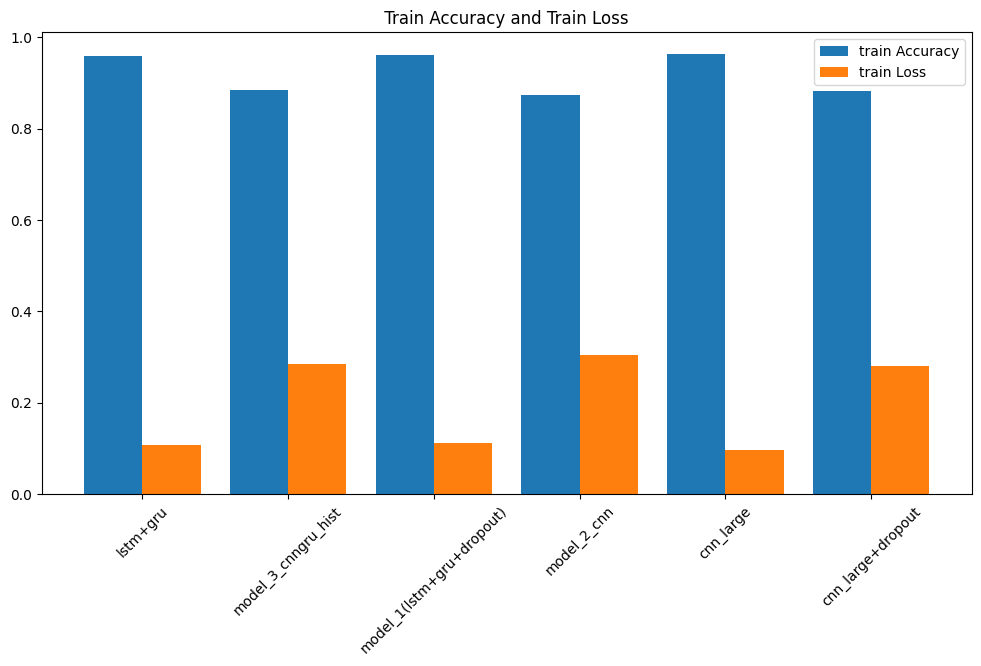

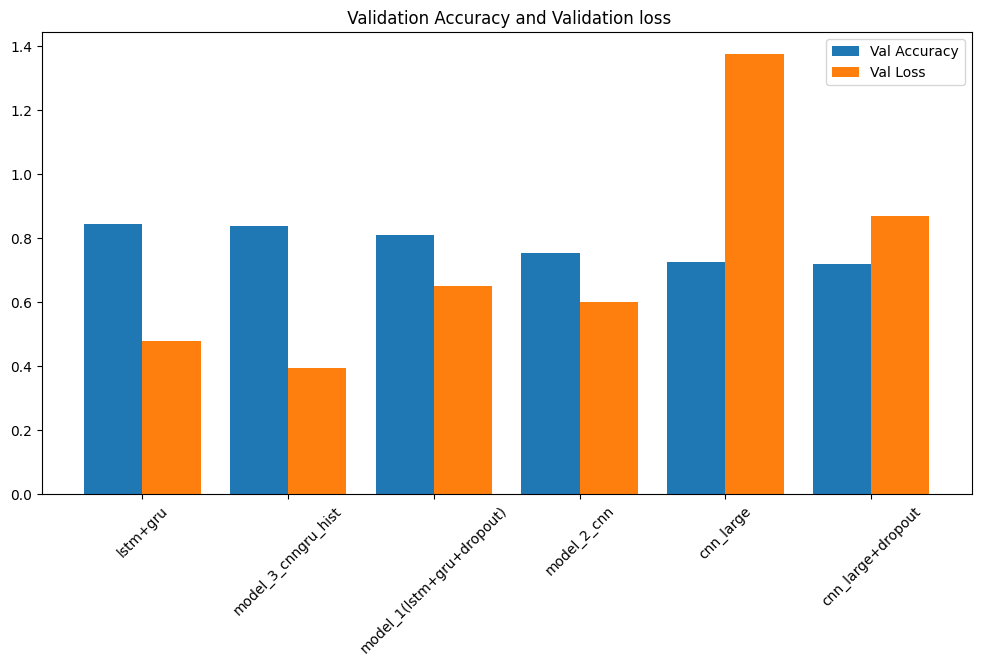

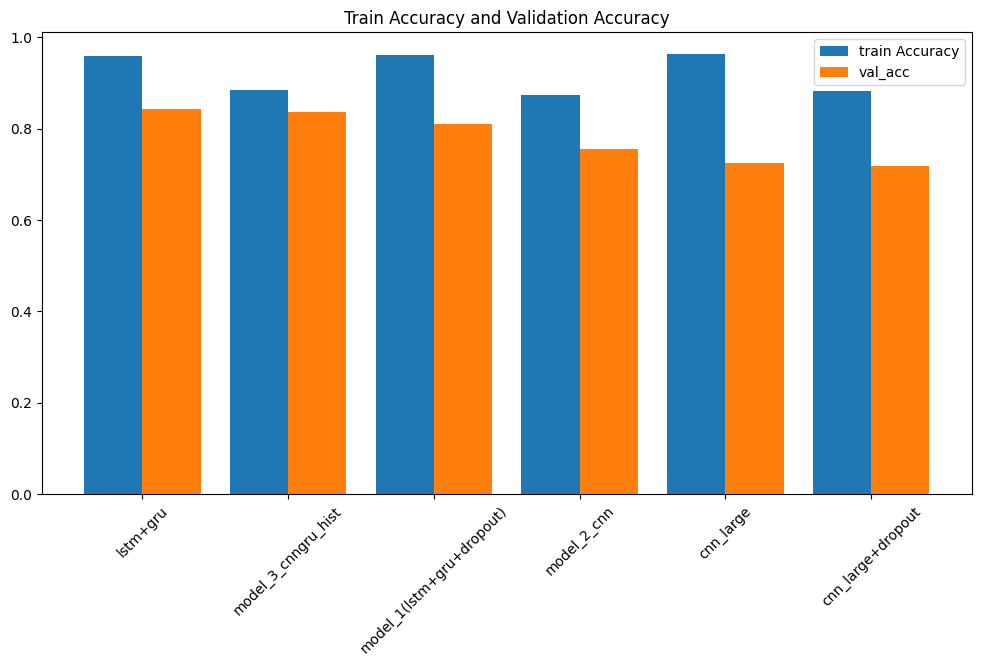

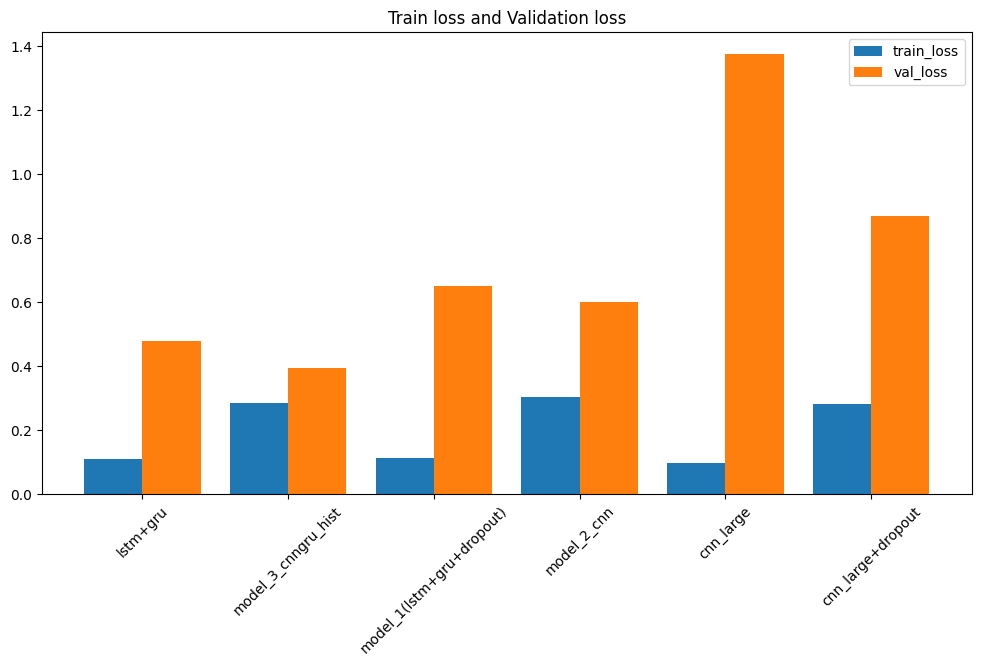

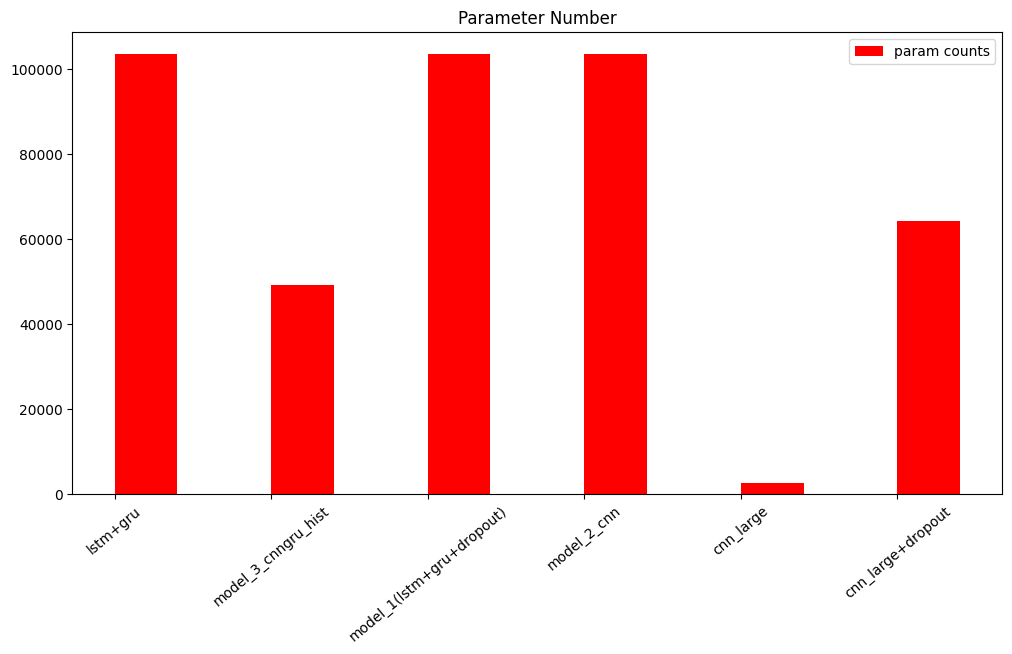

In [326]:
visualize_results ()

# uploading the data

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
os.listdir()

['.config', 'drive', 'sample_data']

In [7]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/ML_Datasets/EEGs_Nigeria.zip', 'r') as data:
    data.extractall('data')

In [8]:
os.listdir()

['.config', 'drive', 'data', 'sample_data']

# Preprocessing data

In [9]:
!pip install mne -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 97.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [10]:
import mne
print(mne.__version__)

1.12.1


In [11]:
def convertDF2MNE(sub):
    info = mne.create_info(list(sub.columns), ch_types=['eeg'] * len(sub.columns), sfreq=128)
    info.set_montage('standard_1020')
    data=mne.io.RawArray(sub.T, info)
    data.set_eeg_reference()
    data.filter(l_freq=1,h_freq=30)
    epochs=mne.make_fixed_length_epochs(data,duration=5,overlap=1)
    epochs=epochs.drop_bad()
    return epochs.get_data()

In [12]:
meta_data_path = '/content/drive/MyDrive/ML_Datasets/metadata_nigeria.csv'
meta_df = pd.read_csv(meta_data_path)
meta_df.head(5)

,subject.id,recordedPeriod,startTime,session.id,first_condition,remarks,Group,csv.file
0,6,270,26/9/2016 13:13,1,open,NaN,control,signal-6-1.csv.gz
1,9,271,26/9/2016 13:30,1,closed,NaN,control,signal-9-1.csv.gz
2,10,272,26/9/2016 13:36,1,open,eyes closed at 2:40,control,signal-10-1.csv.gz
3,11,274,26/9/2016 13:42,2,closed,no.11.1 failed >> 11.2 is the right one,control,signal-11-2.csv.gz
4,11,1,26/9/2016 13:42,1,closed,no.11.1 failed >> 11.2 is the right one,control,signal-11-1.csv.gz


# Reading the edf data of healthy persons and patients by filering the subject id from meta data and creating a new df array  and converting both patient and healthty array to mne  

In [13]:

EP_sub = meta_df['subject.id'][meta_df['Group']=='epilepsy']
CT_sub = meta_df['subject.id'][meta_df['Group']=='control']
def appender(items,limit):
  iter = 0
  item = []
  for i in items:
    if (iter==limit):
      break
    try:
      reader = pd.read_csv('data/EEGs_Nigeria/signal-{}-1.csv.gz'.format(i), compression='gzip')
      item.append(reader)
      iter=iter+1
    except:
      try:
        reader = pd.read_csv('data/EEGs_Nigeria/signal-{}-2.csv.gz'.format(i), compression='gzip')
        item.append(reader)
        iter=iter+1
      except:
        pass
  return item
Epilepsy = appender(EP_sub,51)
Control = appender(CT_sub,46)
Epilepsy2 = [i.iloc[:,1:15] for i in  Epilepsy]
Control2 = [i.iloc[:,1:15] for i in  Control]
idd_subject =[convertDF2MNE(i) for i in  Epilepsy2]
tdc_subject = [convertDF2MNE(i) for i in  Control2]

Creating RawArray with float64 data, n_channels=14, n_times=34304
    Range : 0 ... 34303 =      0.000 ...   267.992 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (3.305 s)

Not setting metadata
66 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 66 events and 640 original time points ...
0 bad epochs drop

# Labeling the data as 0 and 1 and grouping time spans  of same person  using group list

In [14]:
import numpy as np

In [59]:
control_epochs_labels=[len(i)*[0] for i in tdc_subject]
patients_epochs_labels=[len(i)*[1] for i in idd_subject]

data_list=tdc_subject+idd_subject
label_list=control_epochs_labels+patients_epochs_labels
groups_list=[[i]*len(j) for i, j in enumerate(data_list)]




In [51]:
data_array=np.concatenate(data_list)
label_array=np.concatenate(label_list)
group_array=np.concatenate(groups_list)
data_array=np.moveaxis(data_array,1,2)

print(data_array.shape,label_array.shape,group_array.shape)

ValueError: need at least one array to concatenate

## method 2


In [52]:
Epilepsy_epochs = mne.concatenate_epochs(idd_subject)
Control_epochs = mne.concatenate_epochs(tdc_subject)


IndexError: list index out of range

In [74]:
print(len(data_list))
print(len(label_list))
print(len(groups_list))

0
0
0


In [70]:
print("tdc_subject:", len(tdc_subject))
print("idd_subject:", len(idd_subject))

print("sample tdc:", type(tdc_subject[0]) if len(tdc_subject) > 0 else None)
print("sample idd:", type(idd_subject[0]) if len(idd_subject) > 0 else None)

tdc_subject: 0
idd_subject: 0
sample tdc: None
sample idd: None


## the issue was  eeg data set was loading inside data directory defined while extractall('data') . not my working directory .
 reader = pd.read_csv('EEGs_Nigeria/signal-{}-1.csv.gz'.format(i), compression='gzip') shoule be
 reader = pd.read_csv('data/EEGs_Nigeria/signal-{}-1.csv.gz'.format(i), compression='gzip')


In [15]:
import numpy as np

In [16]:
control_epochs_labels=[len(i)*[0] for i in tdc_subject]
patients_epochs_labels=[len(i)*[1] for i in idd_subject]

data_list=tdc_subject+idd_subject
label_list=control_epochs_labels+patients_epochs_labels
groups_list=[[i]*len(j) for i, j in enumerate(data_list)]

# labeling data
data_array=np.concatenate(data_list)
label_array=np.concatenate(label_list)
group_array=np.concatenate(groups_list)
data_array=np.moveaxis(data_array,1,2)

print(data_array.shape,label_array.shape,group_array.shape)

(6127, 640, 14) (6127,) (6127,)


# train test split

In [17]:
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
gkf=GroupKFold()

In [18]:
for train_index, val_index in gkf.split(data_array, label_array, groups=group_array):
    train_features,train_labels=data_array[train_index],label_array[train_index]
    val_features,val_labels=data_array[val_index],label_array[val_index]
    scaler=StandardScaler()
    train_features = scaler.fit_transform(train_features.reshape(-1, train_features.shape[-1])).reshape(train_features.shape)
    val_features = scaler.transform(val_features.reshape(-1, val_features.shape[-1])).reshape(val_features.shape)

In [90]:
train_features.shape , train_features[0].shape

((4892, 640, 14), (640, 14))

#Models

In [19]:
import tensorflow as tf

In [120]:

tf.random.set_seed(42)
from tensorflow.keras import layers



# Create LSTM model
inputs = layers.Input(shape=(640,14), dtype="float32")
#x = layers.LSTM(64)(inputs)  dimension error . by default return sequence is false . next gru expects 3 dim
x = layers.LSTM(64,return_sequences=True)(inputs)
x=layers.BatchNormalization()(x)
x=layers.GRU(64,return_sequences=True)(x)
x=layers.Dropout(0.3)(x)
x=layers.LSTM(64, return_sequences=True)(x)
x=layers.Dropout(.2)(x)
x=layers.GRU(64)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_1 = tf.keras.Model(inputs, outputs, name="model_1_LSTM_GRU")



model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
model_1.summary()



Model: "model_1_LSTM_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_53 (InputLayer)     │ (None, 640, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 640, 64)        │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 640, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_33 (GRU)                    │ (None, 640, 64)        │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 640, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 640, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 640, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_34 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,489 (404.25 KB)

 Trainable params: 103,361 (403.75 KB)

 Non-trainable params: 128 (512.00 B)

In [133]:
model_names.append(model_1)

In [22]:
model_1.count_params()

103489

In [121]:
model_1_history = model_1.fit(train_features,
                              train_labels,
                              epochs=20,
                              validation_data=(val_features, val_labels),
                            )

Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 27s 153ms/step - accuracy: 0.5613 - loss: 0.6809 - val_accuracy: 0.5862 - val_loss: 0.6773
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.6417 - loss: 0.6422 - val_accuracy: 0.5765 - val_loss: 0.6831
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - accuracy: 0.6175 - loss: 0.6498 - val_accuracy: 0.6324 - val_loss: 0.6555
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.6738 - loss: 0.6109 - val_accuracy: 0.6105 - val_loss: 0.6658
Epoch 5/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.6341 - loss: 0.6390 - val_accuracy: 0.6607 - val_loss: 0.6211
Epoch 6/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.6995 - loss: 0.5868 - val_accuracy: 0.6478 - val_loss: 0.6436
Epoch 7/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.6881 - loss: 0.5968 - val_accuracy: 0.6656 - val_loss: 0.6137
Epoch 8/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.7054 - loss: 0.5769 -

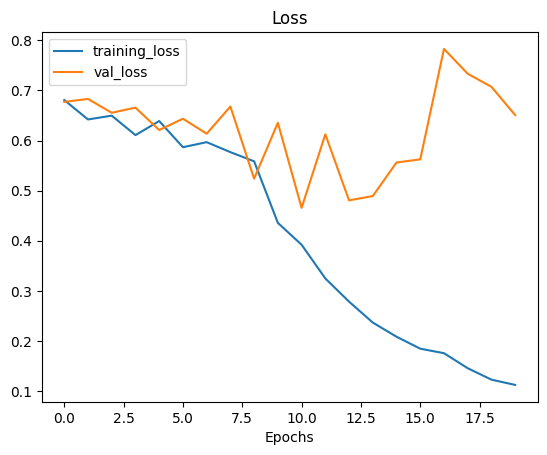

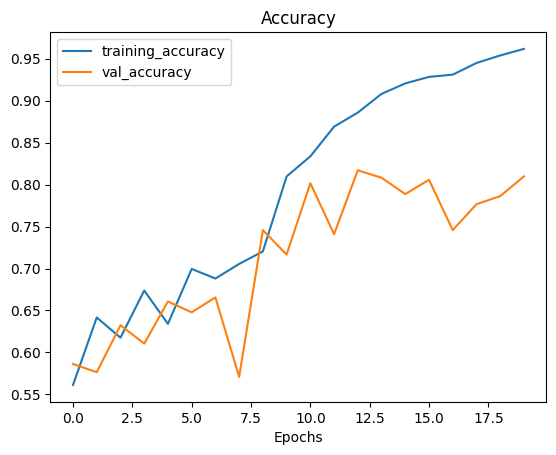

In [267]:
plot_loss_curves(model_1_history)

In [27]:
model_1_history.history['val_accuracy']

[0.6008096933364868,
 0.6170040369033813,
 0.5935222506523132,
 0.6340081095695496,
 0.653441309928894,
 0.7093117237091064,
 0.7570850253105164,
 0.755465567111969,
 0.7797570824623108,
 0.7757084965705872]

# trying with 20 epochs

In [26]:
#### trying with 20 epochs

model_1_history_20 = model_1.fit(train_features,
                              train_labels,
                              epochs=20,
                              validation_data=(val_features, val_labels),
                            )

Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 24s 158ms/step - accuracy: 0.9270 - loss: 0.1908 - val_accuracy: 0.7976 - val_loss: 0.5812
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.9244 - loss: 0.1869 - val_accuracy: 0.7684 - val_loss: 0.6621
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 14s 94ms/step - accuracy: 0.9446 - loss: 0.1484 - val_accuracy: 0.7765 - val_loss: 0.6368
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.9305 - loss: 0.1760 - val_accuracy: 0.8049 - val_loss: 0.6010
Epoch 5/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.9503 - loss: 0.1354 - val_accuracy: 0.8243 - val_loss: 0.4999
Epoch 6/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.9522 - loss: 0.1266 - val_accuracy: 0.8202 - val_loss: 0.4665
Epoch 7/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 29s 190ms/step - accuracy: 0.9632 - loss: 0.1035 - val_accuracy: 0.8081 - val_loss: 0.5779
Epoch 8/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - accuracy: 0.9689 - loss: 0.091

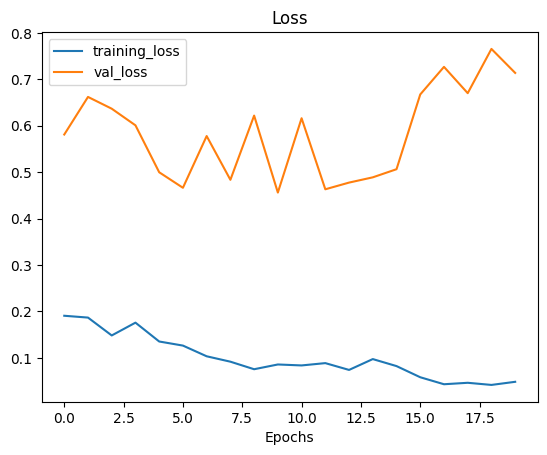

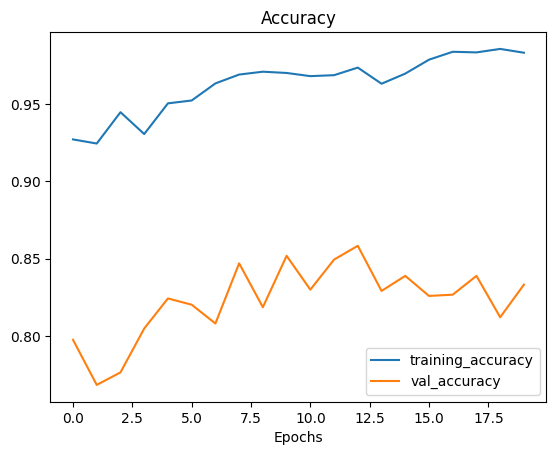

In [32]:
plot_loss_curves(model_1_history_20)

In [54]:
# new same model with 20 epoch
tf.random.set_seed(42)
from tensorflow.keras import layers



# Create LSTM model
inputs = layers.Input(shape=(640,14), dtype="float32")
#x = layers.LSTM(64)(inputs)  dimension error . by default return sequence is false . next gru expects 3 dim
x = layers.LSTM(64,return_sequences=True)(inputs)
x=layers.BatchNormalization()(x)
x=layers.GRU(64,return_sequences=True)(x)
x=layers.Dropout(0.3)(x)
x=layers.LSTM(64, return_sequences=True)(x)
x=layers.Dropout(.2)(x)
x=layers.GRU(64)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_1_20 = tf.keras.Model(inputs, outputs, name="model_1_LSTM_GRU")





model_1_20.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
model_1_20.summary()

Model: "model_1_LSTM_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 640, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 640, 64)        │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 640, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 640, 64)        │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 640, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 640, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 640, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_10 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,489 (404.25 KB)

 Trainable params: 103,361 (403.75 KB)

 Non-trainable params: 128 (512.00 B)

In [134]:
model_names.append(model_1_20)

In [55]:
his_1_20= model_1_20.fit(train_features,
                              train_labels,
                              epochs=20,
                              validation_data=(val_features, val_labels),
                            )

Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - accuracy: 0.5491 - loss: 0.6859 - val_accuracy: 0.5676 - val_loss: 0.6743
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.6398 - loss: 0.6416 - val_accuracy: 0.6340 - val_loss: 0.6490
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.6707 - loss: 0.6182 - val_accuracy: 0.6632 - val_loss: 0.6289
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.6212 - loss: 0.6487 - val_accuracy: 0.5749 - val_loss: 0.6766
Epoch 5/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.6208 - loss: 0.6504 - val_accuracy: 0.5984 - val_loss: 0.6995
Epoch 6/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.6746 - loss: 0.6112 - val_accuracy: 0.6397 - val_loss: 0.6353
Epoch 7/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.6919 - loss: 0.5900 - val_accuracy: 0.7077 - val_loss: 0.5818
Epoch 8/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.7120 - loss: 0.5671 -

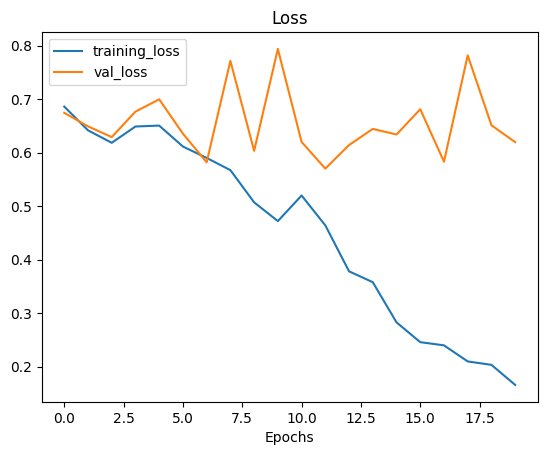

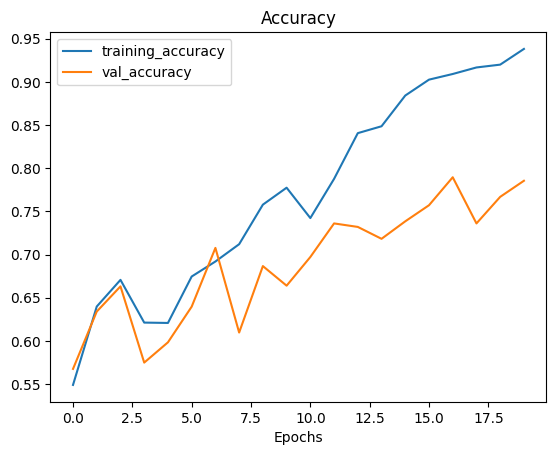

In [56]:
plot_loss_curves(his_1_20)

# no droup out layer

In [62]:
tf.random.set_seed(42)
from tensorflow.keras import layers



# Create LSTM model
inputs = layers.Input(shape=(640,14), dtype="float32")
#x = layers.LSTM(64)(inputs)  dimension error . by default return sequence is false . next gru expects 3 dim
x = layers.LSTM(64,return_sequences=True)(inputs)
x=layers.BatchNormalization()(x)
x=layers.GRU(64,return_sequences=True)(x)

x=layers.LSTM(64, return_sequences=True)(x)

x=layers.GRU(64)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_1_nodrop = tf.keras.Model(inputs, outputs, name="model_1_LSTM_GRU")





model_1_nodrop.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
model_1_nodrop.summary()

Model: "model_1_LSTM_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 640, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 640, 64)        │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 640, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_15 (GRU)                    │ (None, 640, 64)        │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 640, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_16 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,489 (404.25 KB)

 Trainable params: 103,361 (403.75 KB)

 Non-trainable params: 128 (512.00 B)

In [135]:
model_names.append(model_1_nodrop)

In [63]:
model_1__ndrop_hist = model_1_nodrop.fit(train_features,
                              train_labels,
                              epochs=20,
                              validation_data=(val_features, val_labels),
                            )

Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.5675 - loss: 0.6807 - val_accuracy: 0.5717 - val_loss: 0.6752
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.6370 - loss: 0.6460 - val_accuracy: 0.6478 - val_loss: 0.6245
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.6343 - loss: 0.6439 - val_accuracy: 0.6008 - val_loss: 0.6638
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.6576 - loss: 0.6228 - val_accuracy: 0.6267 - val_loss: 0.6375
Epoch 5/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.6997 - loss: 0.5816 - val_accuracy: 0.6745 - val_loss: 0.6070
Epoch 6/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.6938 - loss: 0.5890 - val_accuracy: 0.5652 - val_loss: 0.6651
Epoch 7/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 14s 94ms/step - accuracy: 0.6813 - loss: 0.5822 - val_accuracy: 0.7061 - val_loss: 0.5913
Epoch 8/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.7878 - loss: 0.4682 - 

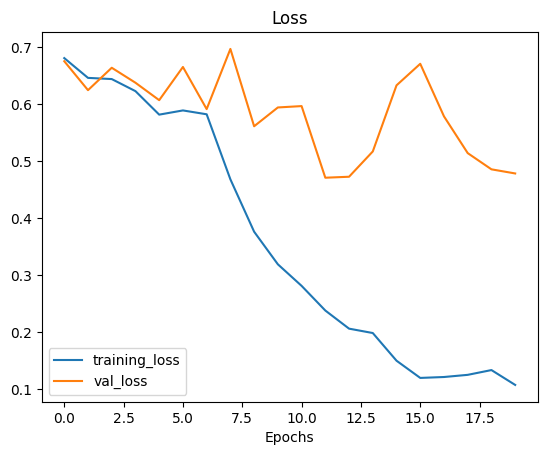

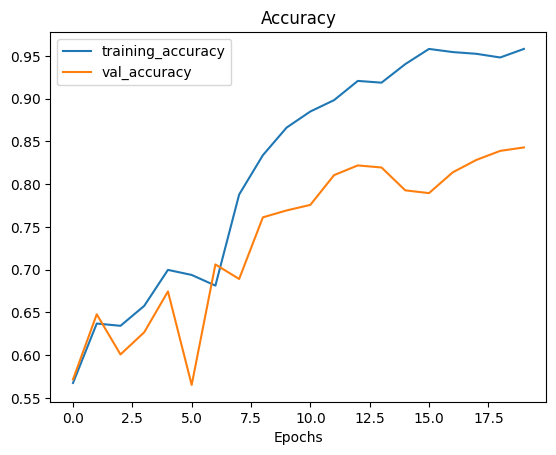

In [64]:
plot_loss_curves(model_1__ndrop_hist)

# CNN model

In [74]:
model_2_cnn = tf.keras.models.Sequential([
  tf.keras.layers.Conv1D(filters=10,
                         kernel_size=3,
                         activation="elu",
                         input_shape=(640,14)),
  tf.keras.layers.BatchNormalization() ,
  tf.keras.layers.Conv1D(10, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(pool_size=2,
                           ),
  tf.keras.layers.Conv1D(10, 3, activation="relu"),
  tf.keras.layers.Conv1D(10, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(10, 3, activation="relu"),
  tf.keras.layers.Conv1D(10, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(10, 3, activation="relu"),
  tf.keras.layers.Conv1D(10, 3, activation="elu"),
  tf.keras.layers.GlobalAveragePooling1D(),

  tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
model_2_cnn.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])
model_2_cnn.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 638, 10)        │           430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 638, 10)        │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 636, 10)        │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 318, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 316, 10)        │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 314, 10)        │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 157, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 155, 10)        │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 153, 10)        │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 76, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 74, 10)         │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 72, 10)         │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 10)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,631 (10.28 KB)

 Non-trainable params: 20 (80.00 B)

In [136]:
model_names.append(model_2_cnn)

In [71]:
# Fit the model
model_2_cnn_hist = model_2_cnn.fit(train_features,train_labels,epochs=20,batch_size=128,validation_data=(val_features,val_labels))

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - accuracy: 0.5317 - loss: 0.6893 - val_accuracy: 0.6154 - val_loss: 0.6741
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6036 - loss: 0.6681 - val_accuracy: 0.6397 - val_loss: 0.6363
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6936 - loss: 0.5982 - val_accuracy: 0.7126 - val_loss: 0.5690
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7796 - loss: 0.5102 - val_accuracy: 0.7263 - val_loss: 0.5310
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7999 - loss: 0.4683 - val_accuracy: 0.7506 - val_loss: 0.5035
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8121 - loss: 0.4461 - val_accuracy: 0.7660 - val_loss: 0.4764
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8195 - loss: 0.4271 - val_accuracy: 0.7765 - val_loss: 0.4737
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8256 - loss: 0.4088 - val_accuracy: 0.7765 -

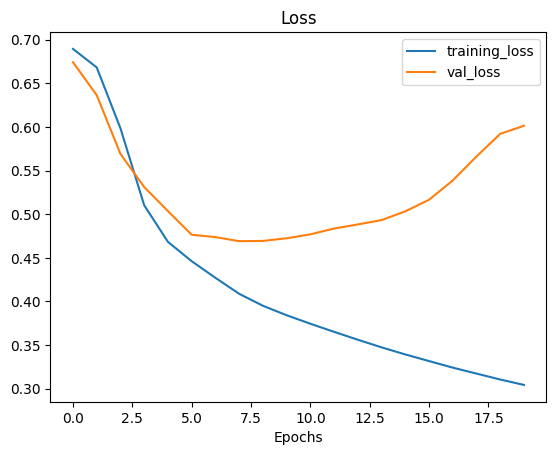

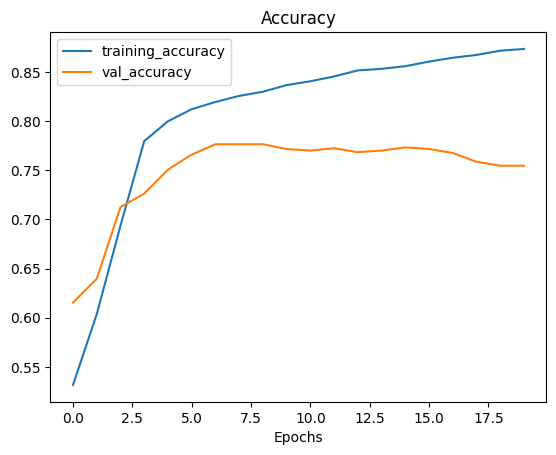

In [72]:
plot_loss_curves(model_2_cnn_hist)

In [75]:
model_2_cnn_hist_50 = model_2_cnn.fit(train_features,train_labels,epochs=50,batch_size=128,validation_data=(val_features,val_labels))

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.5869 - loss: 0.6849 - val_accuracy: 0.6040 - val_loss: 0.6710
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6770 - loss: 0.6230 - val_accuracy: 0.6551 - val_loss: 0.5984
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7686 - loss: 0.5087 - val_accuracy: 0.7304 - val_loss: 0.5437
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7929 - loss: 0.4619 - val_accuracy: 0.7466 - val_loss: 0.5240
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8105 - loss: 0.4347 - val_accuracy: 0.7579 - val_loss: 0.5058
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8183 - loss: 0.4153 - val_accuracy: 0.7709 - val_loss: 0.4929
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8283 - loss: 0.3986 - val_accuracy: 0.7765 - val_loss: 0.4888
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8338 - loss: 0.3821 - val_accuracy: 0.7806 - 

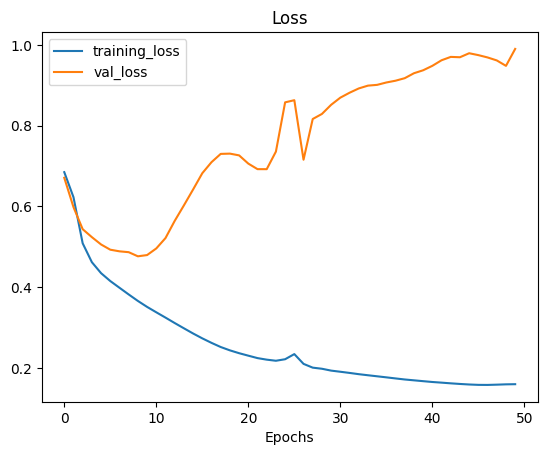

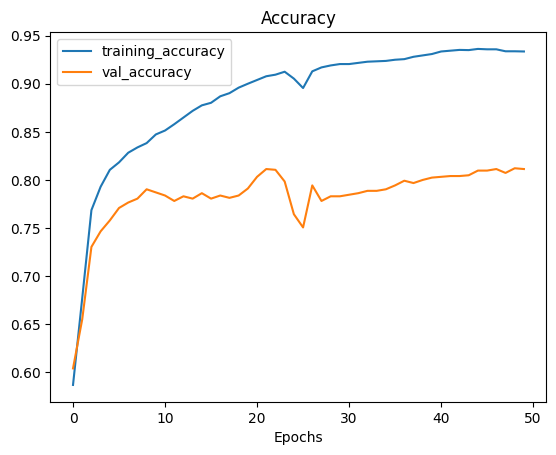

In [76]:
plot_loss_curves(model_2_cnn_hist_50 )

In [97]:
model_2_cnn_large = tf.keras.models.Sequential([
  tf.keras.layers.Conv1D(filters=60,
                         kernel_size=10,
                         activation="elu",
                         input_shape=(640,14)),
  tf.keras.layers.BatchNormalization() ,
  tf.keras.layers.Conv1D(50, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(pool_size=2,
                           ),
  tf.keras.layers.Conv1D(30, 5, activation="relu"),
  tf.keras.layers.Conv1D(30, 5, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(30, 3, activation="relu"),
  tf.keras.layers.Conv1D(30, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(30, 3, activation="relu"),
  tf.keras.layers.Conv1D(30, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(30, 3, activation="elu"),
  tf.keras.layers.Conv1D(30, 5, activation="relu"),
  tf.keras.layers.Conv1D(30, 5, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(30, 3, activation="elu"),
  tf.keras.layers.Conv1D(30, 5, activation="relu"),
  tf.keras.layers.Conv1D(30, 5, activation="elu"),
  tf.keras.layers.GlobalAveragePooling1D(),

  tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
model_2_cnn_large.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])
model_2_cnn_large.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_273 (Conv1D)             │ (None, 631, 60)        │         8,460 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 631, 60)        │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_274 (Conv1D)             │ (None, 629, 50)        │         9,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_114               │ (None, 314, 50)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_275 (Conv1D)             │ (None, 310, 30)        │         7,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_276 (Conv1D)             │ (None, 306, 30)        │         4,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_115               │ (None, 153, 30)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_277 (Conv1D)             │ (None, 151, 30)        │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_278 (Conv1D)             │ (None, 149, 30)        │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_116               │ (None, 74, 30)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_279 (Conv1D)             │ (None, 72, 30)         │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_280 (Conv1D)             │ (None, 70, 30)         │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_117               │ (None, 35, 30)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_281 (Conv1D)             │ (None, 33, 30)         │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_282 (Conv1D)             │ (None, 29, 30)         │         4,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_283 (Conv1D)             │ (None, 25, 30)         │         4,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_118               │ (None, 12, 30)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_284 (Conv1D)             │ (None, 10, 30)         │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_285 (Conv1D)             │ (None, 6, 30)          │         4,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_286 (Conv1D)             │ (None, 2, 30)          │         4,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_24     │ (None, 30)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 64,341 (251.33 KB)

 Trainable params: 64,221 (250.86 KB)

 Non-trainable params: 120 (480.00 B)

In [99]:
model_2_cnn_large_hist_50 = model_2_cnn_large.fit(train_features,train_labels,epochs=20,batch_size=128,validation_data=(val_features,val_labels))

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 39s 463ms/step - accuracy: 0.5971 - loss: 0.6604 - val_accuracy: 0.6551 - val_loss: 0.6276
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7608 - loss: 0.5103 - val_accuracy: 0.7644 - val_loss: 0.5315
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8187 - loss: 0.4059 - val_accuracy: 0.7862 - val_loss: 0.4788
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8493 - loss: 0.3512 - val_accuracy: 0.7814 - val_loss: 0.4838
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8483 - loss: 0.3392 - val_accuracy: 0.7992 - val_loss: 0.4422
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8624 - loss: 0.3227 - val_accuracy: 0.8138 - val_loss: 0.4002
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8526 - loss: 0.3314 - val_accuracy: 0.8024 - val_loss: 0.4423
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8988 - loss: 0.2461 - val_accuracy: 0.8364 -

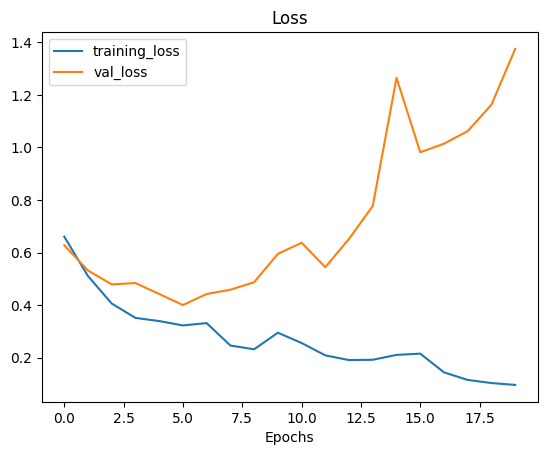

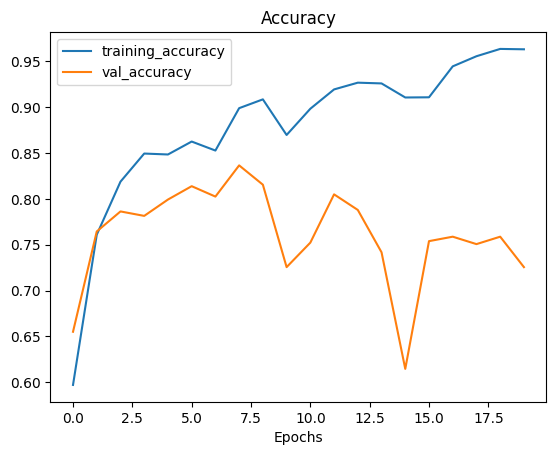

In [100]:
plot_loss_curves(model_2_cnn_large_hist_50)

In [104]:
model_2_cnn_large_drop = tf.keras.models.Sequential([
  tf.keras.layers.Conv1D(filters=60,
                         kernel_size=10,
                         activation="elu",
                         input_shape=(640,14)),
  tf.keras.layers.BatchNormalization() ,
  tf.keras.layers.Conv1D(50, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(pool_size=2,
                           ),
  tf.keras.layers.Conv1D(30, 5, activation="relu"),

  tf.keras.layers.Conv1D(30, 5, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(30, 3, activation="relu"),
  layers.Dropout(0.5),
  tf.keras.layers.Conv1D(30, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(30, 3, activation="relu"),
  layers.Dropout(0.5),
  tf.keras.layers.Conv1D(30, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(30, 3, activation="elu"),
  layers.Dropout(.5),
  tf.keras.layers.Conv1D(30, 5, activation="relu"),
  layers.Dropout(0.5),
  tf.keras.layers.Conv1D(30, 5, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(30, 3, activation="elu"),
  layers.Dropout(0.5),
  tf.keras.layers.Conv1D(30, 5, activation="relu"),
  layers.Dropout(0.5),
  tf.keras.layers.Conv1D(30, 5, activation="elu"),
  tf.keras.layers.GlobalAveragePooling1D(),

  tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
model_2_cnn_large_drop.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])
model_2_cnn_large_drop.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_301 (Conv1D)             │ (None, 631, 60)        │         8,460 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 631, 60)        │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_302 (Conv1D)             │ (None, 629, 50)        │         9,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_124               │ (None, 314, 50)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_303 (Conv1D)             │ (None, 310, 30)        │         7,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_304 (Conv1D)             │ (None, 306, 30)        │         4,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_125               │ (None, 153, 30)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_305 (Conv1D)             │ (None, 151, 30)        │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 151, 30)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_306 (Conv1D)             │ (None, 149, 30)        │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_126               │ (None, 74, 30)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_307 (Conv1D)             │ (None, 72, 30)         │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 72, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_308 (Conv1D)             │ (None, 70, 30)         │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_127               │ (None, 35, 30)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_309 (Conv1D)             │ (None, 33, 30)         │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 33, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_310 (Conv1D)             │ (None, 29, 30)         │         4,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 29, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_311 (Conv1D)             │ (None, 25, 30)         │         4,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_128               │ (None, 12, 30)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_312 (Conv1D)             │ (None, 10, 30)         │         2,73

 Total params: 64,341 (251.33 KB)

 Trainable params: 64,221 (250.86 KB)

 Non-trainable params: 120 (480.00 B)

In [144]:
res = [ i  for i in model_names]
print(res)
model_names.append(model_2_cnn_large_drop)

[<Functional name=model_1_LSTM_GRU, built=True>, <Functional name=model_1_LSTM_GRU, built=True>, <Functional name=model_1_LSTM_GRU, built=True>, <Sequential name=sequential_14, built=True>]


In [105]:
model_2_cnn_large_drop_hist_50 = model_2_cnn_large_drop.fit(train_features,train_labels,epochs=20,batch_size=128,validation_data=(val_features,val_labels))

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 42s 502ms/step - accuracy: 0.4914 - loss: 0.7044 - val_accuracy: 0.4818 - val_loss: 0.6942
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4996 - loss: 0.6940 - val_accuracy: 0.5287 - val_loss: 0.6926
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.5035 - loss: 0.6958 - val_accuracy: 0.4850 - val_loss: 0.6935
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5235 - loss: 0.6921 - val_accuracy: 0.5077 - val_loss: 0.6929
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6002 - loss: 0.6745 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6885 - loss: 0.6173 - val_accuracy: 0.5976 - val_loss: 0.6769
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7394 - loss: 0.5402 - val_accuracy: 0.7085 - val_loss: 0.6170
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7833 - loss: 0.4809 - val_accuracy: 0.7360 -

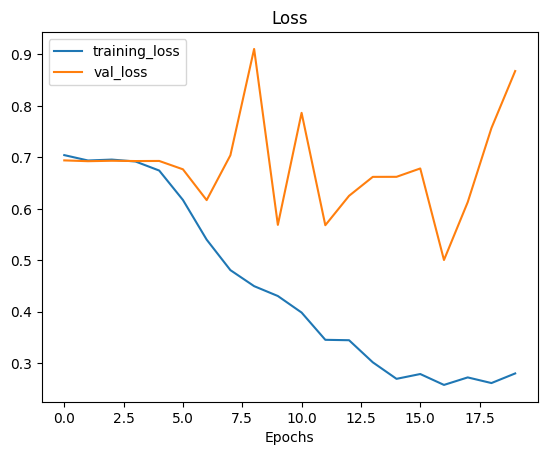

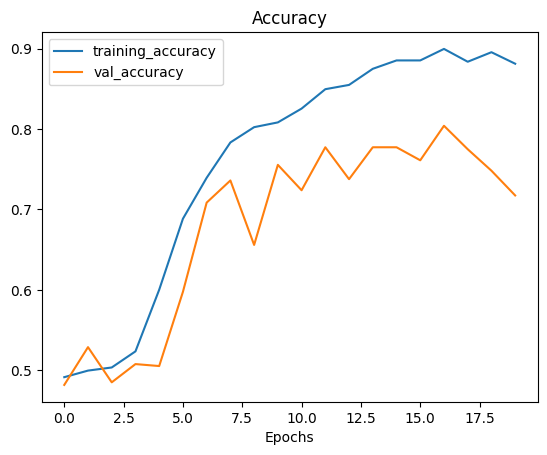

In [108]:
plot_loss_curves(model_2_cnn_large_drop_hist_50)

# cnn + gru

In [113]:
model_3_cnn_gru = tf.keras.models.Sequential([
  tf.keras.layers.Conv1D(filters=10,
                         kernel_size=3,
                         activation="elu",
                         input_shape=(640,14)),
  tf.keras.layers.BatchNormalization() ,
  tf.keras.layers.Conv1D(10, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(pool_size=2,
                           ),
  tf.keras.layers.Conv1D(10, 3, activation="relu"),

  tf.keras.layers.Conv1D(10, 3, activation="elu"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.GRU( 64, return_sequences="True"),
  tf.keras.layers.Conv1D(10, 3, activation="relu"),
  tf.keras.layers.GRU( 64, return_sequences="True"),
  tf.keras.layers.MaxPool1D(2),
  tf.keras.layers.Conv1D(10, 3, activation="relu"),
  tf.keras.layers.GRU( 64),

  tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
model_3_cnn_gru.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])
model_3_cnn_gru.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_343 (Conv1D)             │ (None, 638, 10)        │           430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 638, 10)        │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_344 (Conv1D)             │ (None, 636, 10)        │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_141               │ (None, 318, 10)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_345 (Conv1D)             │ (None, 316, 10)        │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_346 (Conv1D)             │ (None, 314, 10)        │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_142               │ (None, 157, 10)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_28 (GRU)                    │ (None, 157, 64)        │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_347 (Conv1D)             │ (None, 155, 10)        │         1,930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_29 (GRU)                    │ (None, 155, 64)        │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_143               │ (None, 77, 64)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_348 (Conv1D)             │ (None, 75, 10)         │         1,930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_30 (GRU)                    │ (None, 64)             │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,101 (191.80 KB)

 Trainable params: 49,081 (191.72 KB)

 Non-trainable params: 20 (80.00 B)

In [114]:
model_3_cnngru_hist = model_3_cnn_gru.fit(train_features,train_labels,epochs=20,batch_size=128,validation_data=(val_features,val_labels))

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5119 - loss: 0.6925 - val_accuracy: 0.5538 - val_loss: 0.6861
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5832 - loss: 0.6739 - val_accuracy: 0.5425 - val_loss: 0.6855
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7165 - loss: 0.5726 - val_accuracy: 0.7320 - val_loss: 0.5584
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7852 - loss: 0.4870 - val_accuracy: 0.6664 - val_loss: 0.6997
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7905 - loss: 0.4667 - val_accuracy: 0.7579 - val_loss: 0.5585
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8146 - loss: 0.4274 - val_accuracy: 0.7530 - val_loss: 0.6091
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8281 - loss: 0.4042 - val_accuracy: 0.7652 - val_loss: 0.5477
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8342 - loss: 0.3889 - val_accuracy: 0.7806 - v

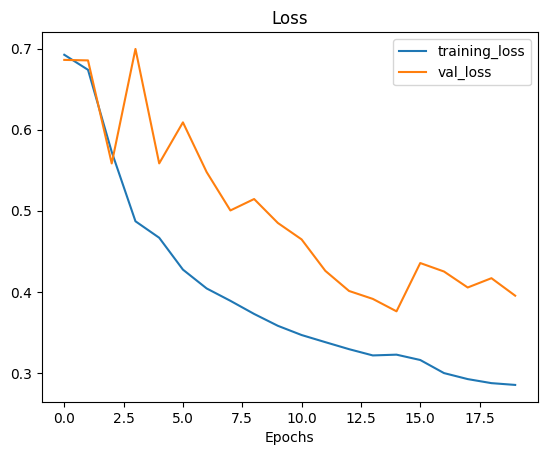

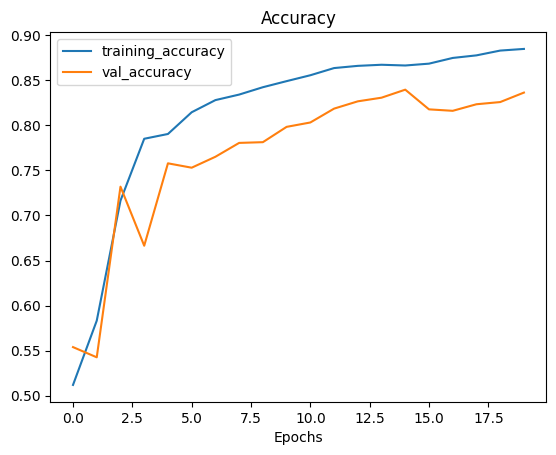

In [115]:
plot_loss_curves(model_3_cnngru_hist)

In [145]:
model_names.append(model_3_cnn_gru)

In [158]:
models_history = [model_1_history,model_1__ndrop_hist,model_2_cnn_hist,model_2_cnn_large_hist_50 ,model_2_cnn_large_drop_hist_50,model_3_cnngru_hist]
for i in models :
  print(i.history['val_accuracy'])

[0.5862348079681396, 0.5765182375907898, 0.6323886513710022, 0.6105263233184814, 0.6607287526130676, 0.647773265838623, 0.6655870676040649, 0.5708501935005188, 0.7457489967346191, 0.71659916639328, 0.8016194105148315, 0.7408906817436218, 0.8170040249824524, 0.8080971837043762, 0.7886639833450317, 0.8056679964065552, 0.7457489967346191, 0.7765182256698608, 0.7862347960472107, 0.8097165822982788]
[0.5716599225997925, 0.647773265838623, 0.6008096933364868, 0.626720666885376, 0.6744939088821411, 0.5651822090148926, 0.7060728669166565, 0.6890688538551331, 0.76113361120224, 0.7692307829856873, 0.7757084965705872, 0.8105263113975525, 0.8218623399734497, 0.8194332122802734, 0.7927125692367554, 0.7894737124443054, 0.8137651681900024, 0.8283400535583496, 0.8388664126396179, 0.8429149985313416]
[0.6153846383094788, 0.6396760940551758, 0.7125505805015564, 0.7263157963752747, 0.7506073117256165, 0.7659919261932373, 0.7765182256698608, 0.7765182256698608, 0.7765182256698608, 0.7716599106788635, 0.77

In [132]:
model_names = []

In [151]:
print([i for i in models_history])

len(models_history),len(model_names)

[<keras.src.callbacks.history.History object at 0x7c858fc70e00>, <keras.src.callbacks.history.History object at 0x7c86049ae8a0>, <keras.src.callbacks.history.History object at 0x7c85a595eff0>, <keras.src.callbacks.history.History object at 0x7c858e4f8e00>, <keras.src.callbacks.history.History object at 0x7c85a704a750>, <keras.src.callbacks.history.History object at 0x7c85564a68a0>]


(6, 6)

In [159]:
models_history = [model_1_history,model_1__ndrop_hist,model_2_cnn_hist,model_2_cnn_large_hist_50 ,model_2_cnn_large_drop_hist_50,model_3_cnngru_hist]
for i in models :
  print(i.history['val_accuracy'])

[0.5862348079681396, 0.5765182375907898, 0.6323886513710022, 0.6105263233184814, 0.6607287526130676, 0.647773265838623, 0.6655870676040649, 0.5708501935005188, 0.7457489967346191, 0.71659916639328, 0.8016194105148315, 0.7408906817436218, 0.8170040249824524, 0.8080971837043762, 0.7886639833450317, 0.8056679964065552, 0.7457489967346191, 0.7765182256698608, 0.7862347960472107, 0.8097165822982788]
[0.5716599225997925, 0.647773265838623, 0.6008096933364868, 0.626720666885376, 0.6744939088821411, 0.5651822090148926, 0.7060728669166565, 0.6890688538551331, 0.76113361120224, 0.7692307829856873, 0.7757084965705872, 0.8105263113975525, 0.8218623399734497, 0.8194332122802734, 0.7927125692367554, 0.7894737124443054, 0.8137651681900024, 0.8283400535583496, 0.8388664126396179, 0.8429149985313416]
[0.6153846383094788, 0.6396760940551758, 0.7125505805015564, 0.7263157963752747, 0.7506073117256165, 0.7659919261932373, 0.7765182256698608, 0.7765182256698608, 0.7765182256698608, 0.7716599106788635, 0.77

# Visualizing my findings

In [278]:
params = []
val_acc = []
val_loss= []
train_acc=[]
train_loss=[]

for i in model_names:
  params.append(i.count_params())

for i in models_history:
   val_acc.append  (i.history['val_accuracy'][-1])
   val_loss.append (i.history['val_loss'][-1])
   train_loss.append (i.history['loss'][-1])
   train_acc.append (i.history['accuracy'][-1])


In [279]:
len(val_acc) , len(val_loss), len(params) , len(train_acc), len(train_loss)

(6, 6, 6, 6, 6)

In [281]:
df = pd.DataFrame({
    "parameters": params,
    "val_accuracy": val_acc,
    "val_loss": val_loss,
    "train_accuracy": train_acc,
    "train_loss": train_loss
}, index=model_names)

In [282]:
df

,parameters,val_accuracy,val_loss,train_accuracy,train_loss
"<Functional name=model_1_LSTM_GRU, built=True>",103489,0.809717,0.650845,0.961570,0.112159
"<Functional name=model_1_LSTM_GRU, built=True>",103489,0.842915,0.478538,0.958095,0.107995
"<Functional name=model_1_LSTM_GRU, built=True>",103489,0.754656,0.601228,0.873467,0.304326
"<Sequential name=sequential_14, built=True>",2651,0.725506,1.374705,0.963001,0.096215
"<Sequential name=sequential_37, built=True>",64341,0.717409,0.867821,0.881235,0.280167
"<Sequential name=sequential_42, built=True>",49101,0.836437,0.395235,0.884914,0.285138


In [283]:
models_name_string= ['model_1(lstm+gru+dropout)','lstm+gru','model_2_cnn','cnn_large' ,'cnn_large+dropout','model_3_cnngru_hist']

In [285]:
df_fixed = pd.DataFrame({

    "model name": models_name_string,
    "parameter_number": params,
    "val_accuracy": val_acc,
    "val_loss": val_loss,
    "train_accuracy": train_acc,
    "train_loss": train_loss
})

In [286]:
df_fixed

,model name,parameter_number,val_accuracy,val_loss,train_accuracy,train_loss
0,model_1(lstm+gru+dropout),103489,0.809717,0.650845,0.961570,0.112159
1,lstm+gru,103489,0.842915,0.478538,0.958095,0.107995
2,model_2_cnn,103489,0.754656,0.601228,0.873467,0.304326
3,cnn_large,2651,0.725506,1.374705,0.963001,0.096215
4,cnn_large+dropout,64341,0.717409,0.867821,0.881235,0.280167
5,model_3_cnngru_hist,49101,0.836437,0.395235,0.884914,0.285138


In [297]:
df_sorted= df_fixed.sort_values("val_accuracy", ascending=False)

In [298]:
df_sorted

,model name,parameter_number,val_accuracy,val_loss,train_accuracy,train_loss
1,lstm+gru,103489,0.842915,0.478538,0.958095,0.107995
5,model_3_cnngru_hist,49101,0.836437,0.395235,0.884914,0.285138
0,model_1(lstm+gru+dropout),103489,0.809717,0.650845,0.961570,0.112159
2,model_2_cnn,103489,0.754656,0.601228,0.873467,0.304326
3,cnn_large,2651,0.725506,1.374705,0.963001,0.096215
4,cnn_large+dropout,64341,0.717409,0.867821,0.881235,0.280167


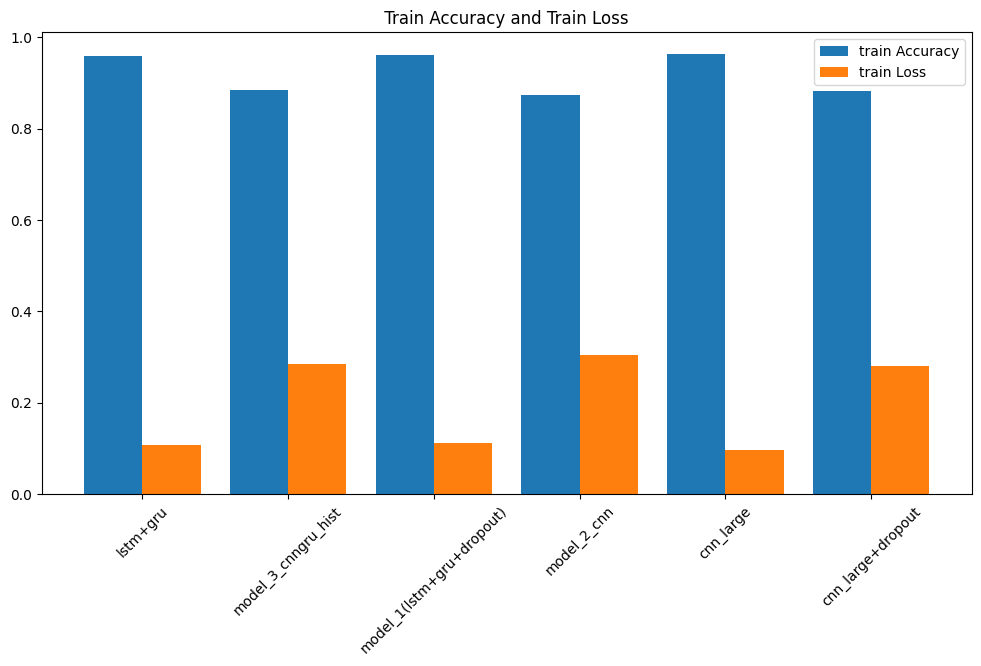

In [307]:
import numpy as np

x = np.arange(len(df_sorted["model name"]))

plt.figure(figsize=(12, 6))

plt.bar(x - 0.2, df_sorted["train_accuracy"], width=0.4, label="train Accuracy")
plt.bar(x + 0.2, df_sorted["train_loss"], width=0.4, label="train Loss")

plt.xticks(x, df_sorted["model name"], rotation=45)
plt.title(" Train Accuracy and Train Loss ")
plt.legend()
plt.show()

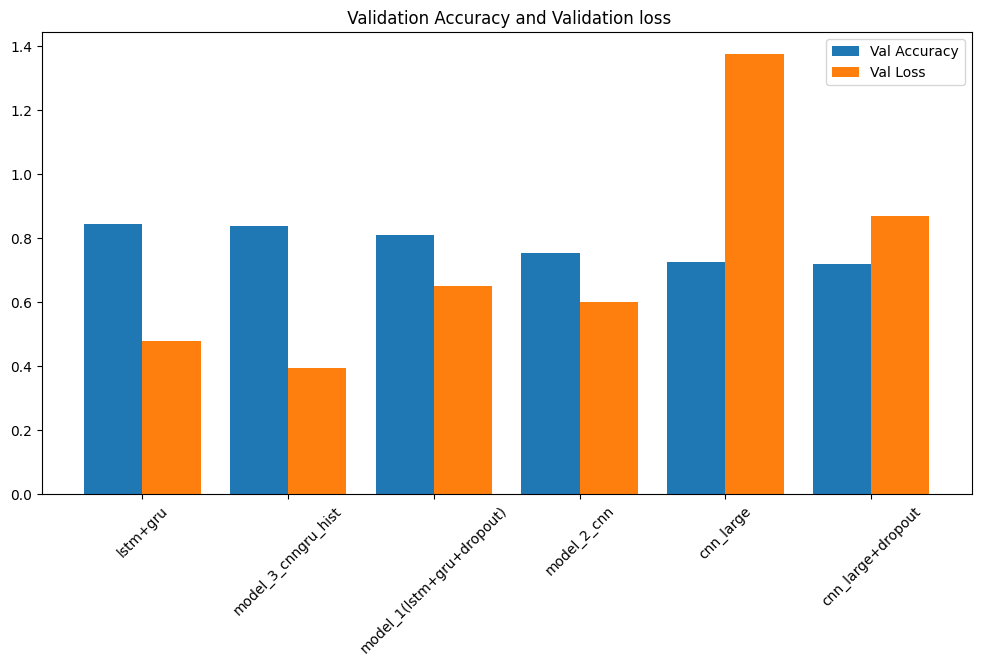

In [308]:
import numpy as np

x = np.arange(len(df_sorted["model name"]))

plt.figure(figsize=(12, 6))

plt.bar(x - 0.2, df_sorted["val_accuracy"], width=0.4, label="Val Accuracy")
plt.bar(x + 0.2, df_sorted["val_loss"], width=0.4, label="Val Loss")

plt.xticks(x, df_sorted["model name"], rotation=45)
plt.title(" Validation Accuracy and Validation loss")
plt.legend()
plt.show()

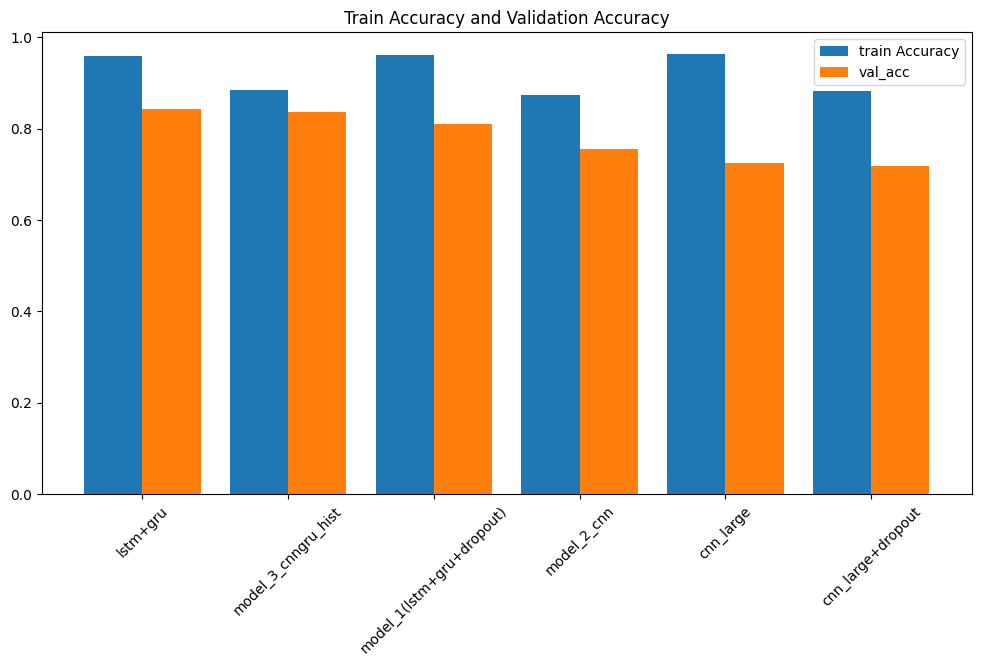

In [306]:
import numpy as np

x = np.arange(len(df_sorted["model name"]))

plt.figure(figsize=(12, 6))

plt.bar(x - 0.2, df_sorted["train_accuracy"], width=0.4, label="train Accuracy")
plt.bar(x + 0.2, df_sorted["val_accuracy"], width=0.4, label="val_acc")

plt.xticks(x, df_sorted["model name"], rotation=45)
plt.title("Train Accuracy and Validation Accuracy")
plt.legend()
plt.show()

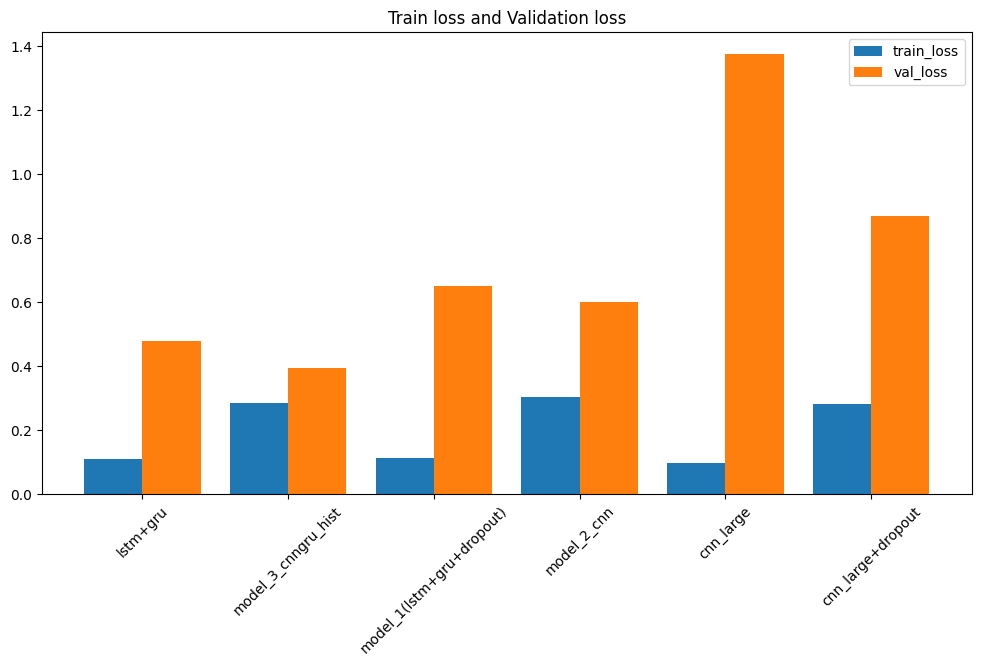

In [305]:
import numpy as np

x = np.arange(len(df_sorted["model name"]))

plt.figure(figsize=(12, 6))

plt.bar(x - 0.2, df_sorted["train_loss"], width=0.4, label="train_loss")
plt.bar(x + 0.2, df_sorted["val_loss"], width=0.4, label="val_loss")

plt.xticks(x, df_sorted["model name"], rotation=45)
plt.title("Train loss and Validation loss")
plt.legend()
plt.show()

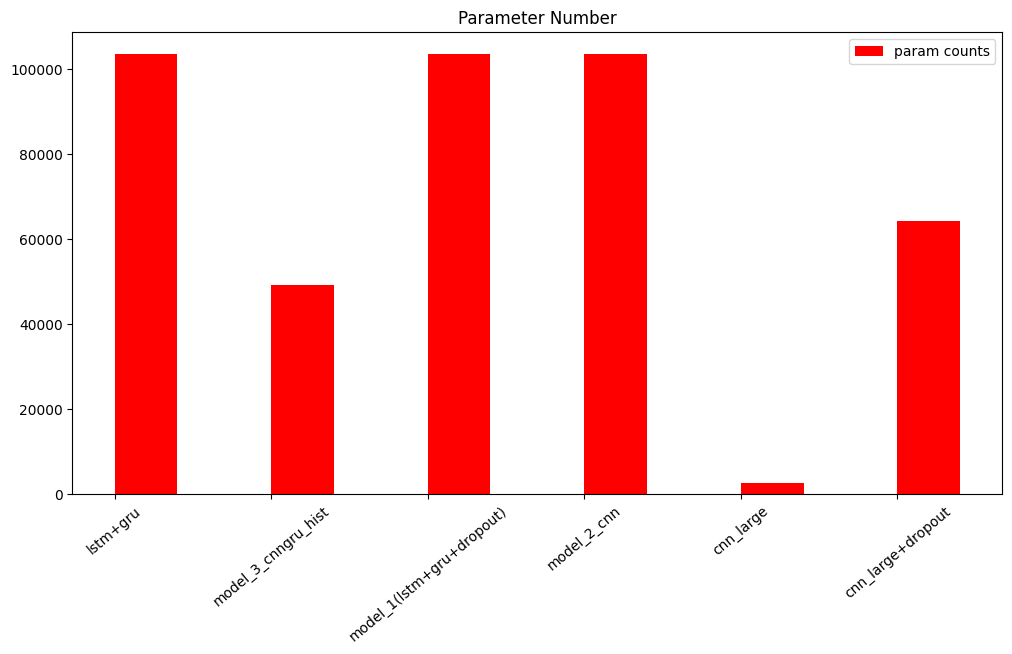

In [310]:
import numpy as np

x = np.arange(len(df_sorted["model name"]))

plt.figure(figsize=(12, 6))


plt.bar(x + 0.2, df_sorted["parameter_number"], width=0.4, label="param counts",   color="red")

plt.xticks(x, df_sorted["model name"], rotation=40)
plt.title("Parameter Number")
plt.legend()
plt.show()

# cnn+gru model  achieved val_accuracy almost same of lstm+gru but the parameter counts was very negligible comparing to lstm+gru. So its the best model among them. also loss is very low its 0.39 in validation data

In [321]:
def visualize_results(df=df_sorted):
    import numpy as np
    x = np.arange(len(df["model name"]))

    plt.figure(figsize=(12, 6))

    plt.bar(x - 0.2, df_sorted["train_accuracy"], width=0.4, label="train Accuracy")
    plt.bar(x + 0.2, df_sorted["train_loss"], width=0.4, label="train Loss")

    plt.xticks(x, df_sorted["model name"], rotation=45)
    plt.title(" Train Accuracy and Train Loss ")
    plt.legend()
    plt.show()




    plt.figure(figsize=(12, 6))

    plt.bar(x - 0.2, df_sorted["val_accuracy"], width=0.4, label="Val Accuracy")
    plt.bar(x + 0.2, df_sorted["val_loss"], width=0.4, label="Val Loss")

    plt.xticks(x, df_sorted["model name"], rotation=45)
    plt.title(" Validation Accuracy and Validation loss")
    plt.legend()
    plt.show()



    plt.figure(figsize=(12, 6))

    plt.bar(x - 0.2, df_sorted["train_accuracy"], width=0.4, label="train Accuracy")
    plt.bar(x + 0.2, df_sorted["val_accuracy"], width=0.4, label="val_acc")

    plt.xticks(x, df_sorted["model name"], rotation=45)
    plt.title("Train Accuracy and Validation Accuracy")
    plt.legend()
    plt.show()


    plt.figure(figsize=(12, 6))

    plt.bar(x - 0.2, df_sorted["train_loss"], width=0.4, label="train_loss")
    plt.bar(x + 0.2, df_sorted["val_loss"], width=0.4, label="val_loss")

    plt.xticks(x, df_sorted["model name"], rotation=45)
    plt.title("Train loss and Validation loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 6))


    plt.bar(x + 0.2, df_sorted["parameter_number"], width=0.4, label="param counts",   color="red")

    plt.xticks(x, df_sorted["model name"], rotation=40)
    plt.title("Parameter Number")
    plt.legend()
    plt.show()